# Exercícios do Capítulo 1 — Processamento Digital de Sinais

Capítulo 1 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 1

O Capítulo 1 apresenta os conceitos básicos do Processamento Digital de Sinais (DSP), incluindo:
- Definição de sinais e sistemas
- Diferenças entre sinais contínuos e discretos
- Convolução
- Equações de Diferença
- Periocidade de Sinais

## Objetivos Principais:
- Utilizar pacotes do Python para representar e manipular sinais discretos.
-  Implementação de uma função que receba dois sinais discretos retorne o resultado da convolução discreta entre eles.
-  Análise da complexidade computacional da implementação.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos com implementações de Convolução

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Scipy.signal: https://docs.scipy.org/doc/scipy/reference/signal.html#convolution
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

Representando o Impulso Unitário

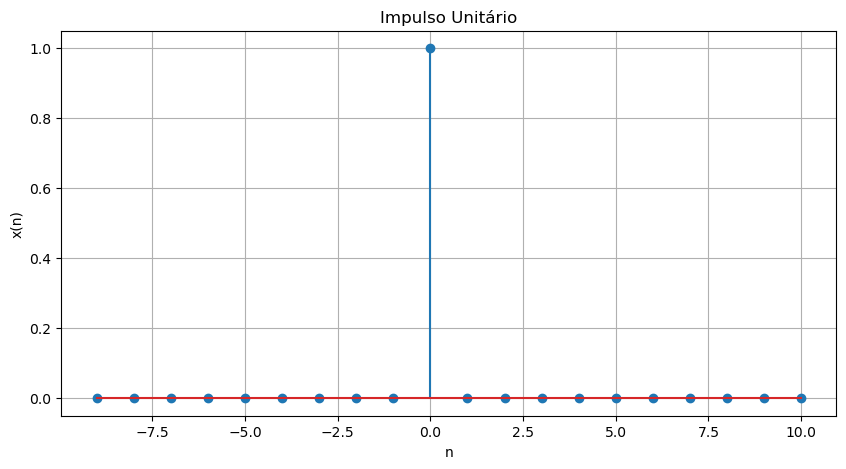

In [25]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando o impulso unitário

n= np.arange(-9,11) #criando o vetor n de -9 a 10
impulse= np.where(n==0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o impulso unitário
plt.figure(figsize=(10, 5))#Criando a figura e definindo o tamanho


plt.stem(n,impulse)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

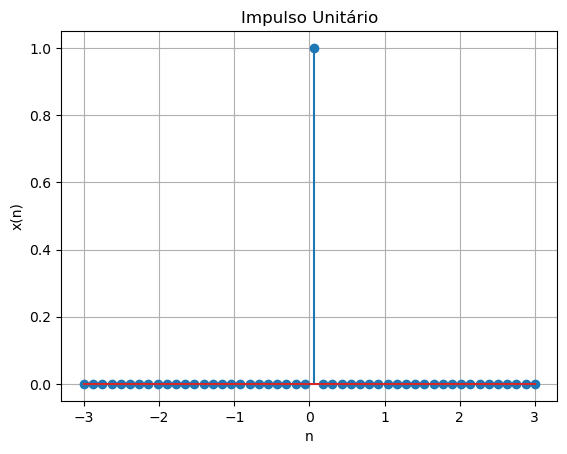

In [ ]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando uma função impulso unitário deslocado em k


def impulse(n_inicio, n_fim, k=0, amplitude=1.0):
    """
    Gera um sinal de impulso discreto, possivelmente deslocado.
    O deslocamento (n-k) é controlado pelo parâmetro 'posicao'.
    """
    n = np.linspace(n_inicio, n_fim, 50) #cria o vetor n com 200 pontos entre n_inicio e n_fim

    rough = np.argmin(np.abs(n-k)) #encontra o índice mais próximo de posicao 
    #np.argmin= encontra o índice do menor valor 
    #np.abs= retorna o valor absoluto


    sinal = np.zeros_like(n)# Cria um vetor de zeros com o mesmo formato de n

    sinal[rough] = amplitude #define o valor do impulso na posição aproximada 
    return n, sinal


amostra, delta = impulse(-3, 3, k=0, amplitude=1.0) #chama a função para gerar o impulso unitário


# Plotando o impulso unitário
plt.figure()#Criando a figura e definindo o tamanho

plt.stem(amostra,delta)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

<span style="font-size:24px">
   Representando o Degrau Unitário
</span>


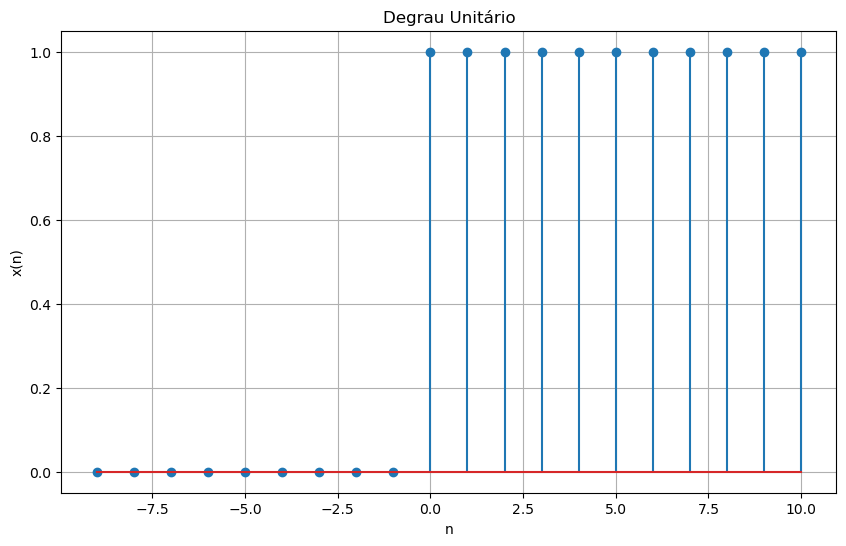

In [ ]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando o a função Degrau 

n= np.arange(-9,11) #criando o vetor n de -9 a 10
impulse= np.where(n>=0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o Degrau Unitário
plt.figure()#Criando a figura e definindo o tamanho


plt.stem(n,impulse)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Degrau Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico


<span style="font-size:24px">
    Representando Sinais Senoidais
</span>

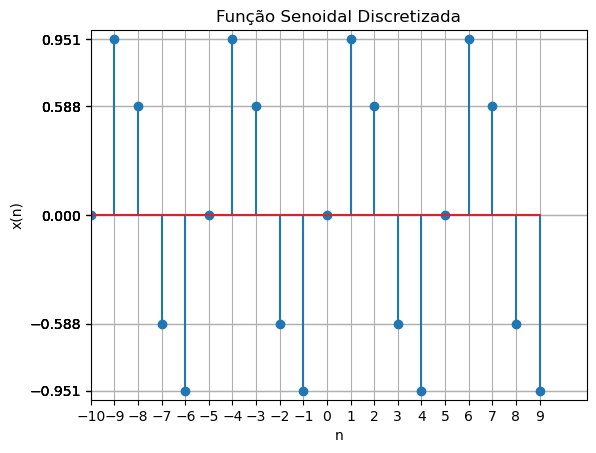

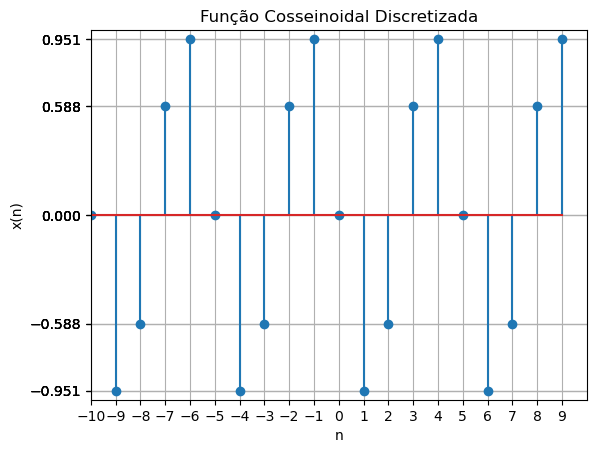

In [30]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando Sinais Senoidais
N= 10 #numero de amostras

n= np.arange(-N,N) #criando o vetor n de 1000 amostras
A= 1 #amplitude do sinal
t= 5 #periodo do sinal
f= 1/t #frequência do sinal

phi= 0 #fase do sinal
senoide= A * np.sin((2 * np.pi * f * n)  + phi) #criando o sinal senoidal
cossenoide= A*np.cos((2*np.pi*f*n) + (phi+ np.pi/2)) #criando o sinal cossenoidal
# Plotando o Sinais Senoidais
plt.figure()#Criando a figura e definindo o tamanho


plt.stem(n,senoide)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Função Senoidal Discretizada')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y
plt.xticks(n)   # Define os valores do eixo x para mostrar todos os pontos
plt.yticks(senoide)  # Define os valores do eixo y para mostrar todos os pontos
plt.xlim(-N, N+1)  # Define o limite do eixo x para mostrar todos os pontos
plt.ylim(-A, A)  # Define o limite do eixo y para mostrar todos   

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

# Plotando o Sinais Cossenoidais
plt.figure()#Criando a figura e definindo o tamanho

plt.stem(n,cossenoide)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Função Cosseinoidal Discretizada')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y
plt.xticks(n)   # Define os valores do eixo x para mostrar todos os pontos
plt.yticks(cossenoide)  # Define os valores do eixo y para mostrar todos os pontos
plt.xlim(-N, N)  # Define o limite do eixo x para mostrar todos os pontos
plt.ylim(-A, A)  # Define o limite do eixo y para mostrar todos   

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

<span style="font-size:24px">
    Realizar a Convolução em python, tentar refazer a função np.convolve da biblioteca NumPy
</span>
## Convolução em Tempo Discreto

A convolução em tempo discreto é uma operação essencial para analisar sistemas lineares e invariantes no tempo (LTI). Ela permite determinar a saída de um sistema para qualquer entrada, conhecendo apenas a resposta ao impulso do sistema.

A convolução de dois sinais discretos $x[n]$ e $h[n]$ é definida por:

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

Onde:
- $x[n]$: sinal de entrada
- $h[n]$: resposta ao impulso do sistema
- $y[n]$: saída do sistema

## Implementação com Vetores Finitos em Python

Como lidamos com vetores de tamanho finito em Python, a fórmula costuma ser reescrita como:

$$
y[n] \;=\; \sum_{k=0}^{M-1} x[k]\;\cdot\;h[n - k]
$$


## Dimensões dos Vetores

- \(x\) tem tamanho \(M\)  
- \(h\) tem tamanho \(N\)  
- \(y\) terá tamanho \(M + N - 1\)  

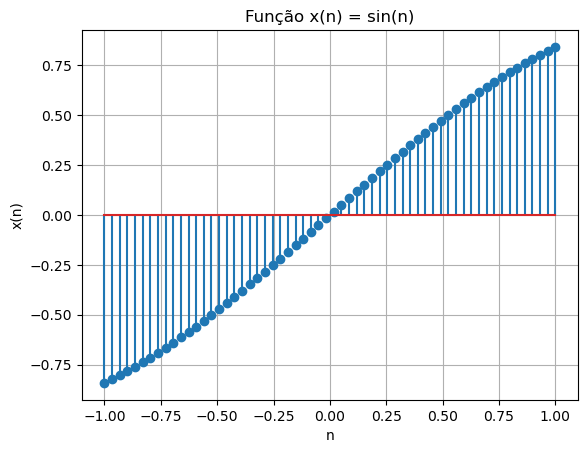

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

amostras =np.linspace(-1, 1, 60)  # criando o vetor h_n de -10 a 10 com 1000 amostras
x_n=np.sin(amostras)   

# Plotando a função h(t)
plt.figure()  # Criando a figura e definindo o tamanho
plt.stem(amostras,x_n)
plt.title('Função x(n) = sin(n)')  # Título do gráfico
plt.xlabel('n')  # Rótulo do eixo x
plt.ylabel('x(n)')  # Rótulo do eixo y
plt.grid(True)  # Adiciona uma grade ao gráfico



plt.grid(True)#adiciona uma grade ao gráfico